## Environment setup 

In [2]:
%pip install accelerate bitsandbytes google-cloud-aiplatform peft trl scikit-learn tokenizers torch transformers unsloth evaluate python-dotenv sentencepiece protobuf matplotlib

Note: you may need to restart the kernel to use updated packages.


## import library

In [5]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments
import evaluate
from datasets import load_dataset
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from huggingface_hub import login

## Huggingface setup

In [6]:
load_dotenv()
hf_token = os.getenv("HUGFACE_TOKEN")
if hf_token: 
    login(token=hf_token)
    print("Successfully logged in to Hugging Face.")
else:
    print("HUGFACE_TOKEN not found in environment variables. Please set it to access Hugging Face resources.")

Successfully logged in to Hugging Face.


## Load Dataset

In [13]:
from datasets import load_dataset

print("Loading EMNIST ByClass (62 classes)...")
dataset = load_dataset("perceptube/emnist-byclass")
dataset


Loading EMNIST ByClass (62 classes)...


DatasetNotFoundError: Dataset 'perceptube/emnist-byclass' doesn't exist on the Hub or cannot be accessed.

## visualize data

Counter({45: 2400, 36: 2400, 43: 2400, 15: 2400, 4: 2400, 42: 2400, 26: 2400, 32: 2400, 20: 2400, 1: 2400, 46: 2400, 13: 2400, 24: 2400, 12: 2400, 5: 2400, 17: 2400, 3: 2400, 40: 2400, 14: 2400, 44: 2400, 19: 2400, 29: 2400, 25: 2400, 35: 2400, 28: 2400, 23: 2400, 22: 2400, 34: 2400, 9: 2400, 30: 2400, 38: 2400, 39: 2400, 37: 2400, 31: 2400, 16: 2400, 7: 2400, 2: 2400, 8: 2400, 10: 2400, 6: 2400, 27: 2400, 33: 2400, 11: 2400, 18: 2400, 41: 2400, 0: 2400, 21: 2400})


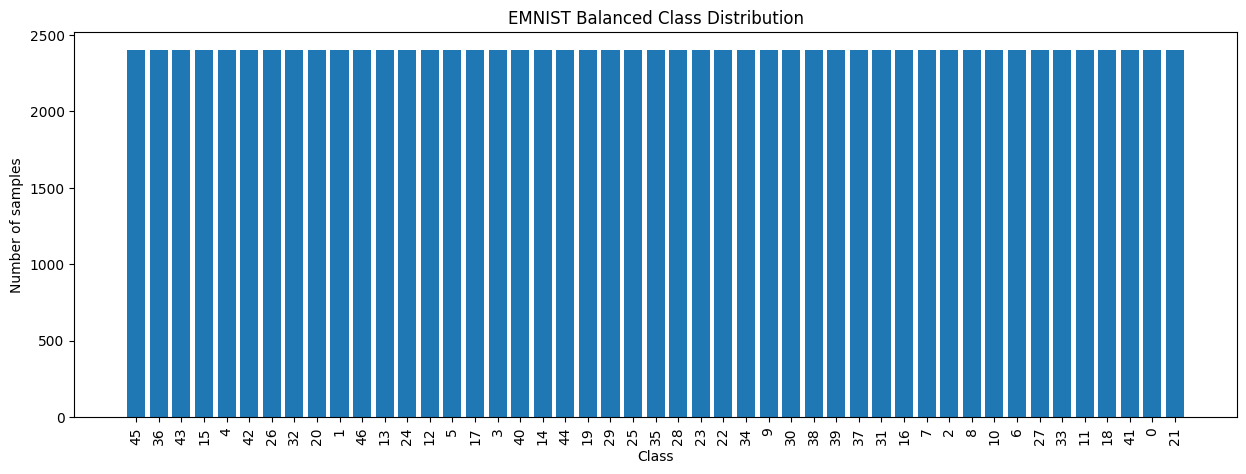

In [ ]:
from collections import Counter

# Lấy toàn bộ label trong train set
labels = dataset["train"]["label"]

# Đếm số lượng từng label
label_counts = Counter(labels)

print(label_counts)
import matplotlib.pyplot as plt

label_names = dataset["train"].features["label"].names

plt.figure(figsize=(15,5))

plt.bar(range(len(label_counts)),
        [label_counts[i] for i in range(len(label_counts))])

plt.xticks(range(len(label_counts)), label_names, rotation=90)

plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("EMNIST ByClass Distribution")

plt.show()